In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema='raw'
"""

table_name = pd.read_sql(query, engine)
print(table_name)

             table_name
0                orders
1              products
2                aisles
3           departments
4  order_products_prior
5  order_products_train


In [4]:
query = """
SELECT
    COUNT(*) AS total_orders,
    COUNT(DISTINCT user_id) AS total_customers
FROM raw.orders
"""

pd.read_sql(query, engine)

,total_orders,total_customers
0,3421083,206209


<Axes: xlabel='order_hour_of_day'>

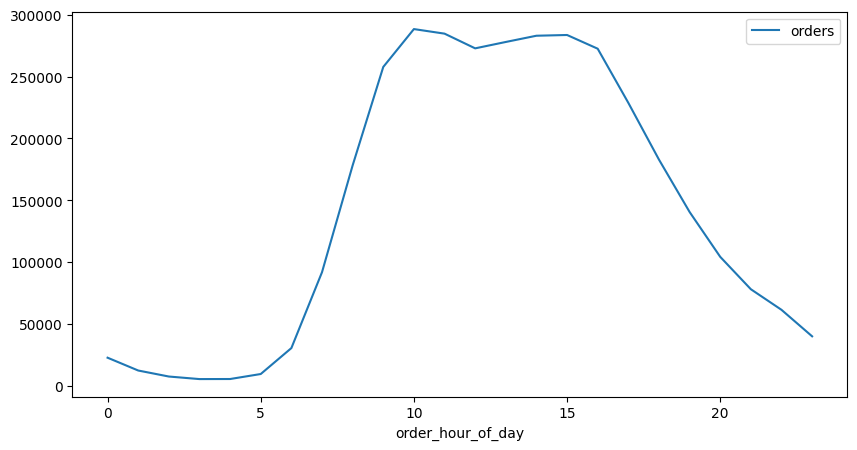

In [5]:
query = """
SELECT
    order_hour_of_day,
    COUNT(*) AS orders
FROM raw.orders
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day
"""

hourly_orders = pd.read_sql(query, engine)

hourly_orders.plot(
    x="order_hour_of_day",
    y="orders",
    kind="line",
    figsize=(10,5)
)

<Axes: xlabel='order_dow'>

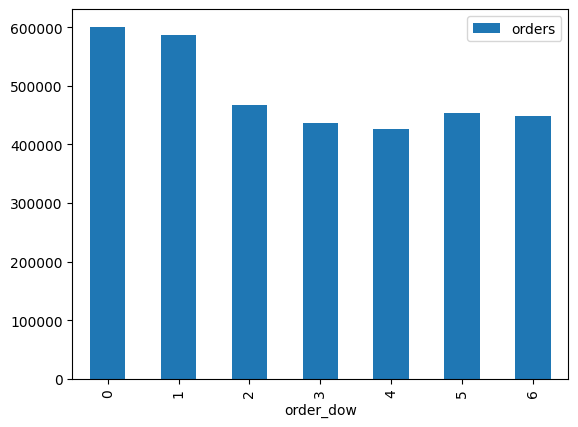

In [6]:
query = """
SELECT
    order_dow,
    COUNT(*) AS orders
FROM raw.orders
GROUP BY order_dow
ORDER BY order_dow
"""

dow = pd.read_sql(query, engine)

dow.plot(
    x="order_dow",
    y="orders",
    kind="bar"
)

In [7]:
query = """
SELECT
    user_id,
    MAX(order_number) AS total_orders
FROM raw.orders
GROUP BY user_id
"""

customer_orders = pd.read_sql(query, engine)

customer_orders["total_orders"].describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: total_orders, dtype: float64

In [8]:
query = """
SELECT
    AVG(reordered::float) AS reorder_rate
FROM raw.order_products_train
"""

pd.read_sql(query, engine)

,reorder_rate
0,0.598594


In [9]:
query = """
SELECT
    p.product_name,
    COUNT(*) AS total_orders
FROM raw.order_products_prior op
JOIN raw.products p
ON op.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_orders DESC
LIMIT 20
"""

top_products = pd.read_sql(query, engine)

<Axes: xlabel='product_name'>

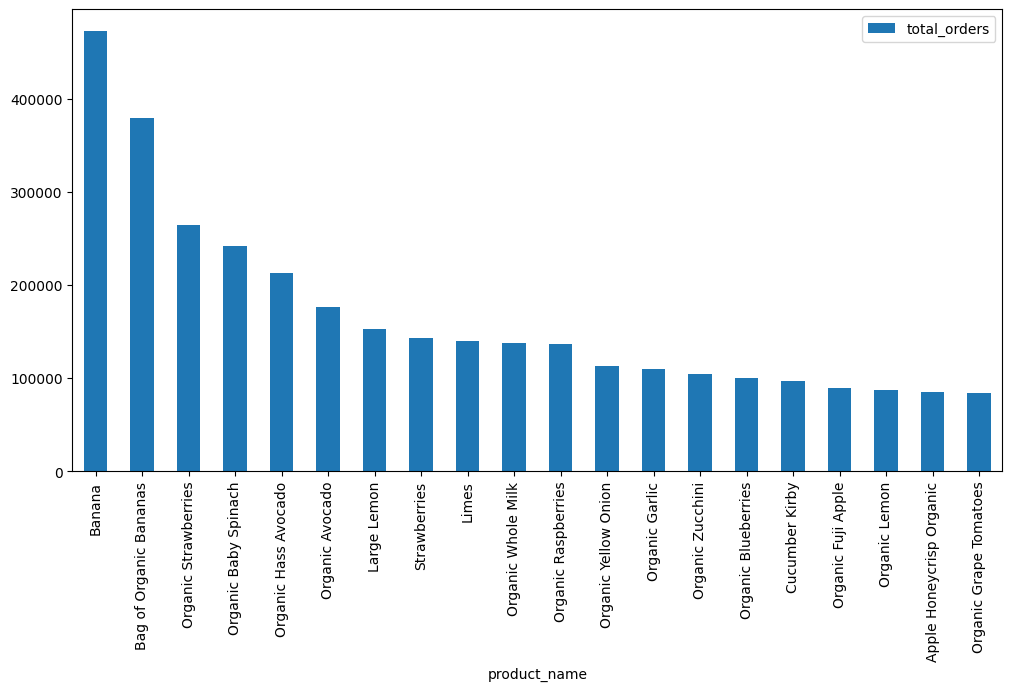

In [10]:
top_products.plot(
    x="product_name",
    y="total_orders",
    kind="bar",
    figsize=(12,6)
)

In [11]:
query = """
SELECT
    d.department,
    COUNT(*) AS sales
FROM raw.order_products_prior op
JOIN raw.products p
ON op.product_id = p.product_id
JOIN raw.departments d
ON p.department_id = d.department_id
GROUP BY d.department
ORDER BY sales DESC
"""

dept_sales = pd.read_sql(query, engine)

<Axes: xlabel='department'>

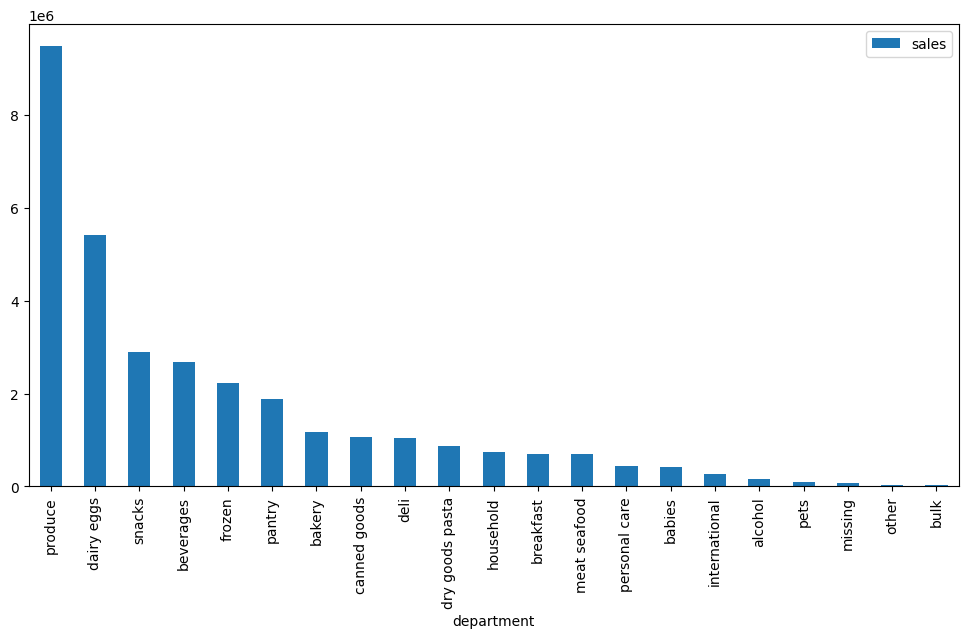

In [12]:
dept_sales.plot(
    x="department",
    y="sales",
    kind="bar",
    figsize=(12,6)
)

In [13]:
query = """
SELECT
    order_id,
    COUNT(*) AS basket_size
FROM raw.order_products_prior
GROUP BY order_id
"""

basket = pd.read_sql(query, engine)

basket["basket_size"].describe()

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64

In [14]:
query = """
SELECT
    user_id,
    MAX(order_number) AS total_orders,
    AVG(days_since_prior_order) AS avg_days_between_orders,
    COUNT(*) AS order_count
FROM raw.orders
GROUP BY user_id
"""

customer_features = pd.read_sql(query, engine)

In [15]:
customer_features.head()

,user_id,total_orders,avg_days_between_orders,order_count
0,1,11,19.000000,11
1,2,15,16.285714,15
2,3,13,12.000000,13
3,4,6,17.000000,6
4,5,5,11.500000,5


In [16]:
query = """
SELECT
    product_id,
    COUNT(*) AS purchase_count,
    AVG(reordered::float) AS reorder_rate
FROM raw.order_products_prior
GROUP BY product_id
"""

product_features = pd.read_sql(query, engine)

In [17]:
product_features.head()

,product_id,purchase_count,reorder_rate
0,1,1852,0.613391
1,2,90,0.133333
2,3,277,0.732852
3,4,329,0.446809
4,5,15,0.600000


In [18]:
query = """
SELECT * FROM raw.order_products_prior
LIMIT 5
"""

pd.read_sql(query, engine)

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
